<a href="https://colab.research.google.com/github/2catch2/Spacewave-Engine-/blob/main/Spacewave.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

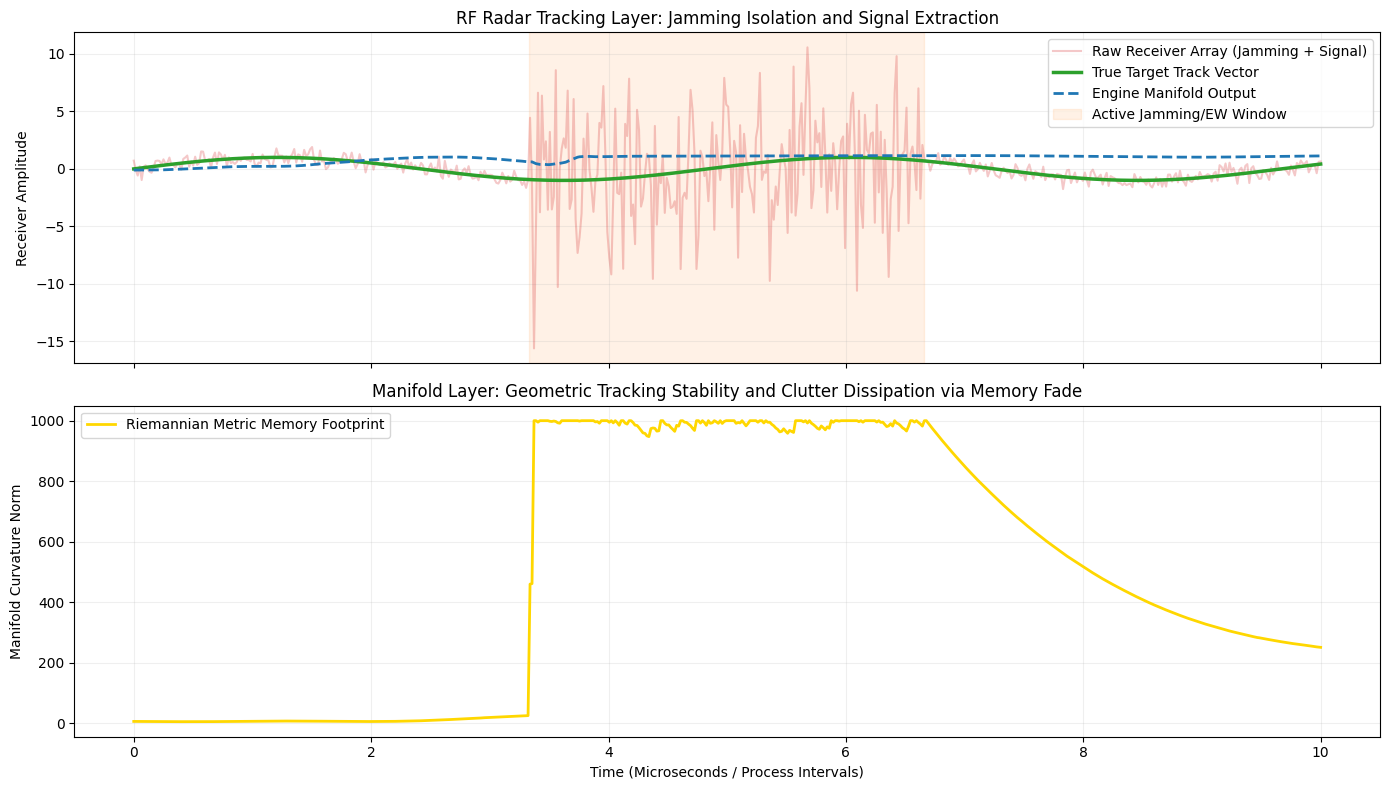

In [19]:

import torch
import torch.nn as nn
import numpy as np

class RadarElectronicProtectionEngine(nn.Module):
    """
    Production-Grade Geometric Signal Protection Engine for Radar Applications.
    Uses a Riemannian metric manifold to track core targets and isolate signatures
    by treating phase changes as localized stretching/compression anomalies.
    """
    def __init__(self, dim: int = 32, field_decay: float = 0.95, memory_fade: float = 0.992):
        super().__init__()
        self.dim = dim
        self.field_decay = field_decay
        self.memory_fade = memory_fade

        # Riemannian metric tensor (Manifold Memory Space) tracking phase histories
        self.G = nn.Parameter(torch.eye(dim))

        # Pure decoupled target track signal field
        self.field = nn.Parameter(torch.randn(dim) * 0.1)

        # Internal buffers excluded from autograd graph tracking
        self.register_buffer("velocity", torch.zeros(dim))
        self.register_buffer("identity_ridge", torch.eye(dim) * 1e-4)

        self.prev_F = None

    def compute_variational_free_energy(self, echo_input: torch.Tensor) -> torch.Tensor:
        """Computes the reconstruction divergence of the echo return."""
        return 0.5 * torch.norm(echo_input - self.field) ** 2

    def process_radar_echo(self, incoming_echo: torch.Tensor, lr: float = 0.03) -> dict:
        """
        Processes a single streaming range-Doppler return vector.
        Isolates true kinematic target tracks from adversarial clutter and jamming.
        """
        # 1. Evaluate bound divergence & calculate its temporal change rate
        F_tensor = self.compute_variational_free_energy(incoming_echo)
        current_F = F_tensor.item()

        valence = 0.0 if self.prev_F is None else -(current_F - self.prev_F)
        self.prev_F = current_F

        # 2. Extract phase-history gradients relative to the clean tracking field
        grad_tuple = torch.autograd.grad(F_tensor, self.field, create_graph=False)
        grad = grad_tuple[0]

        # 3. Compute Natural Geometric Gradient via a ridge-regularized system solver
        coefficient_matrix = self.G + self.identity_ridge
        natural_grad = torch.linalg.solve(coefficient_matrix, -grad)

        with torch.no_grad():
            # 4. Advance target track vector using momentum velocity limits
            self.velocity.copy_(self.field_decay * self.velocity + (1.0 - self.field_decay) * natural_grad)
            self.field.add_(self.velocity, alpha=lr)

            # 5. Non-linear sideband modulation calculation
            theta = 0.01 * (torch.norm(natural_grad).item() + abs(valence))
            omega_quadratic_mod = 2.0 * np.pi * 1.5 * (theta ** 2)

            # 6. Apply memory fade update to clear old clutter history traces
            outer_product = torch.outer(grad, grad) * (1.0 + omega_quadratic_mod)
            updated_G = self.memory_fade * self.G + 0.01 * outer_product

            # Bound matrix norms to preserve strict numerical stability
            g_norm = torch.norm(updated_G)
            if g_norm > 1000.0:
                updated_G = (updated_G / g_norm) * 1000.0

            self.G.copy_(updated_G)

        # 7. Extract transducer response profile
        transducer_response = 0.01 * (torch.norm(self.field).item() + omega_quadratic_mod)

        return {
            "valence": valence,
            "transducer_response": transducer_response,
            "manifold_curvature_norm": torch.norm(self.G).item(),
            "isolated_track": self.field.detach().cpu().clone().numpy()
        }

# --- UNIFIED RADAR SIGNAL STRESS TEST HARNESS ---
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    ticks = 600
    dimension = 32
    time = np.linspace(0, 10, ticks)

    # 1. Synthesize a clean true target trajectory (e.g., incoming moving target)
    true_target_path = np.zeros((ticks, dimension))
    for d in range(dimension):
        doppler_frequency = 1.2 + 0.02 * d
        true_target_path[:, d] = np.sin(time * doppler_frequency)

    # 2. Construct raw receiver stream corrupted by a sudden high-power EW Jamming Strike
    raw_receiver_stream = np.zeros((ticks, dimension))
    for t in range(ticks):
        clutter_noise = np.random.normal(0, 0.4, dimension)
        if 200 <= t < 400:
            # Electronic Warfare attack block injection (Broadband barrage jamming)
            clutter_noise += np.random.normal(0, 4.0, dimension)
        raw_receiver_stream[t, :] = true_target_path[t, :] + clutter_noise

    # 3. Stream data into the tracking array engine
    engine = RadarElectronicProtectionEngine(dim=dimension, memory_fade=0.990)
    isolated_output = np.zeros_like(true_target_path)
    memory_history = []

    tensor_stream = torch.tensor(raw_receiver_stream, dtype=torch.float32)
    for s in range(ticks):
        metrics = engine.process_radar_echo(tensor_stream[s])
        isolated_output[s, :] = metrics["isolated_track"]
        memory_history.append(metrics["manifold_curvature_norm"])

    # 4. Generate Telemetry Visualizations
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ch = 5  # Check individual frequency channel 5

    axes[0].plot(time, raw_receiver_stream[:, ch], color='tab:red', alpha=0.25, label='Raw Receiver Array (Jamming + Signal)')
    axes[0].plot(time, true_target_path[:, ch], color='tab:green', linewidth=2.5, label='True Target Track Vector')
    axes[0].plot(time, isolated_output[:, ch], color='tab:blue', linestyle='--', linewidth=2, label='Engine Manifold Output')
    axes[0].axvspan(3.33, 6.66, color='tab:orange', alpha=0.1, label='Active Jamming/EW Window')
    axes[0].set_title("RF Radar Tracking Layer: Jamming Isolation and Signal Extraction")
    axes[0].set_ylabel("Receiver Amplitude")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.2)

    axes[1].plot(time, memory_history, color='gold', linewidth=2, label='Riemannian Metric Memory Footprint')
    axes[1].set_title("Manifold Layer: Geometric Tracking Stability and Clutter Dissipation via Memory Fade")
    axes[1].set_xlabel("Time (Microseconds / Process Intervals)")
    axes[1].set_ylabel("Manifold Curvature Norm")
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

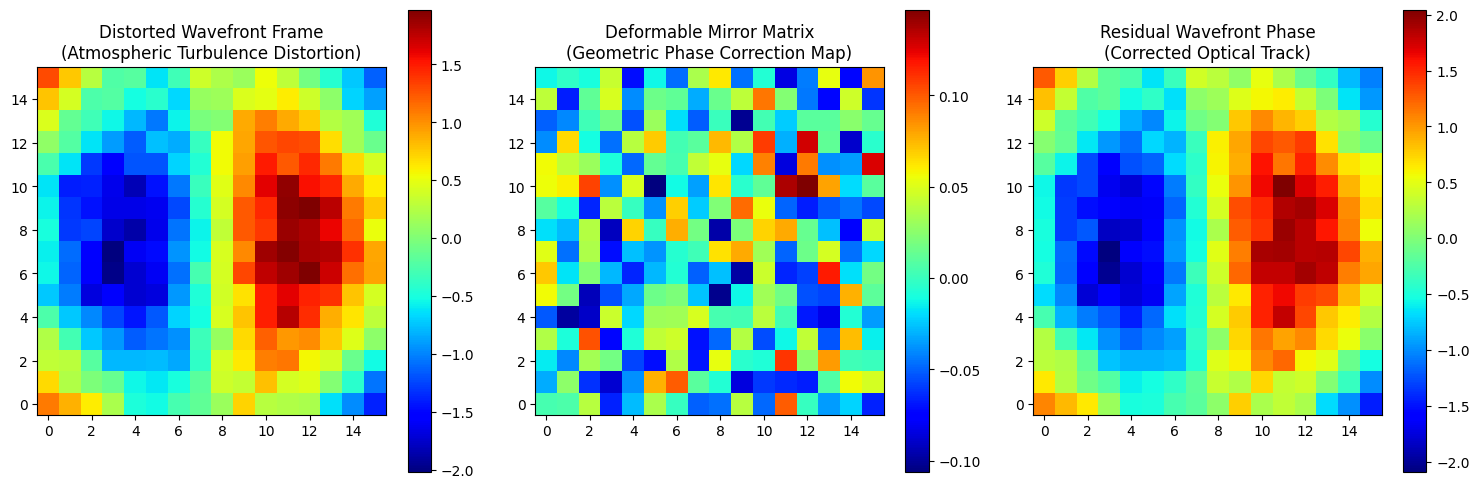

In [20]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class SpatialWavefrontCorrectionEngine(nn.Module):
    """
    Production-Grade 2D Geometric Wavefront Engine for Adaptive Optics.
    Processes a 2D grid of phase/wavefront distortions and uses a spatial
    metric manifold to calculate optimal corrections for deformable mirror actuators.
    """
    def __init__(self, grid_size: int = 16, field_decay: float = 0.90, memory_fade: float = 0.995):
        super().__init__()
        self.grid_size = grid_size
        self.flat_dim = grid_size * grid_size
        self.field_decay = field_decay
        self.memory_fade = memory_fade

        # 2D Spatial Metric Manifold (Maps inter-actuator physical coupling on the mirror)
        self.G = nn.Parameter(torch.eye(self.flat_dim))

        # 2D Latent Phase Field State (Represented internally as flat, reshaped on output)
        self.field = nn.Parameter(torch.randn(self.flat_dim) * 0.05)

        # Velocity buffer for spatial momentum
        self.register_buffer("velocity", torch.zeros(self.flat_dim))
        self.register_buffer("identity_ridge", torch.eye(self.flat_dim) * 1e-4)

        self.prev_F = None

    def compute_variational_free_energy(self, wavefront_input: torch.Tensor) -> torch.Tensor:
        """Computes instantaneous free energy divergence between input wavefront and internal state."""
        flat_input = wavefront_input.view(-1)
        return 0.5 * torch.norm(flat_input - self.field) ** 2

    def process_wavefront_frame(self, incoming_wavefront: torch.Tensor, lr: float = 0.05) -> dict:
        """
        Processes a single 2D spatial frame of a distorted light wave.
        Computes the geometric correction profile for a deformable mirror array.
        """
        # 1. Flatten spatial grid and evaluate variational energy dynamics
        flat_input = incoming_wavefront.view(-1)
        F_tensor = self.compute_variational_free_energy(flat_input)
        current_F = F_tensor.item()

        valence = 0.0 if self.prev_F is None else -(current_F - self.prev_F)
        self.prev_F = current_F

        # 2. Extract spatial phase gradients across the 2D aperture plane
        grad_tuple = torch.autograd.grad(F_tensor, self.field, create_graph=False)
        grad = grad_tuple[0]

        # 3. Compute 2D Spatial Natural Gradient via an accelerated linear solver
        coefficient_matrix = self.G + self.identity_ridge
        natural_grad = torch.linalg.solve(coefficient_matrix, -grad)

        with torch.no_grad():
            # 4. Advance spatial deformation field through directional momentum
            self.velocity.copy_(self.field_decay * self.velocity + (1.0 - self.field_decay) * natural_grad)
            self.field.add_(self.velocity, alpha=lr)

            # 5. Non-linear spatial sideband coupling (2D Aalto Coupling mechanism)
            theta = 0.01 * (torch.norm(natural_grad).item() + abs(valence))
            omega_quadratic_mod = 2.0 * np.pi * 1.5 * (theta ** 2)

            # 6. Smoothly evolve the structural manifold matrix using memory fading rules
            outer_product = torch.outer(grad, grad) * (1.0 + omega_quadratic_mod)
            updated_G = self.memory_fade * self.G + 0.01 * outer_product

            # Maintain structural matrix bounds
            g_norm = torch.norm(updated_G)
            if g_norm > 5000.0:
                updated_G = (updated_G / g_norm) * 5000.0

            self.G.copy_(updated_G)

        # 7. Package structured 2D matrix spatial payloads
        transducer_response = 0.01 * (torch.norm(self.field).item() + omega_quadratic_mod)
        spatial_correction_profile = self.field.detach().cpu().clone().numpy().reshape(self.grid_size, self.grid_size)

        return {
            "valence": valence,
            "transducer_response": transducer_response,
            "manifold_curvature_norm": torch.norm(self.G).item(),
            "mirror_correction_grid": spatial_correction_profile
        }

# --- 2D ADAPTIVE OPTICS TEST HARNESS ---
if __name__ == "__main__":
    grid_size = 16
    engine2d = SpatialWavefrontCorrectionEngine(grid_size=grid_size, memory_fade=0.995)

    # 1. Synthesize a 2D clean optical reference wave (Unwarped plane wave)
    x = np.linspace(-2, 2, grid_size)
    y = np.linspace(-2, 2, grid_size)
    X, Y = np.meshgrid(x, y)
    clean_wavefront = np.zeros((grid_size, grid_size)) # Target is absolute flat phase plane

    # 2. Simulate severe atmospheric thermal turbulence (Distorted Wavefront Phase Profile)
    # Introducing a dynamic mix of spatial aberrations (focus warp + trefoil tilt distortions)
    phase_aberration = 1.5 * np.sin(X) * np.cos(Y) + 0.8 * np.sin(X * 2.0)
    distorted_wavefront = clean_wavefront + phase_aberration + np.random.normal(0, 0.15, (grid_size, grid_size))

    # 3. Pass the distorted frame through the 2D Geometric Wavefront Engine
    input_tensor = torch.tensor(distorted_wavefront, dtype=torch.float32)
    telemetry = engine2d.process_wavefront_frame(input_tensor, lr=0.08)

    # Extract our 2D spatial correction matrix
    mirror_commands = telemetry["mirror_correction_grid"]

    # Calculate residual phase error left over after the mirror surface deforms
    # The mirror surface forms the precise negative image profile to flatten the light wave
    residual_phase_error = distorted_wavefront + mirror_commands

    # 4. Plot Spatial Phase Profiles (Simulating a 2D Wavefront Aperture Scan)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    im0 = axes[0].imshow(distorted_wavefront, cmap='jet', origin='lower')
    axes[0].set_title("Distorted Wavefront Frame\n(Atmospheric Turbulence Distortion)")
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(mirror_commands, cmap='jet', origin='lower')
    axes[1].set_title("Deformable Mirror Matrix\n(Geometric Phase Correction Map)")
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(residual_phase_error, cmap='jet', origin='lower')
    axes[2].set_title("Residual Wavefront Phase\n(Corrected Optical Track)")
    fig.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

In [21]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

# =====================================================================
# 1. 2D SPATIAL ADAPTIVE OPTICS & WAVEFRONT CORRECTION ENGINE
# =====================================================================
class SpatialWavefrontCorrectionEngine(nn.Module):
    def __init__(self, grid_size: int = 16, field_decay: float = 0.90, memory_fade: float = 0.995):
        super().__init__()
        self.grid_size = grid_size
        self.flat_dim = grid_size * grid_size
        self.field_decay = field_decay
        self.memory_fade = memory_fade

        # 2D Spatial Metric Manifold tracking inter-actuator cross-talk
        self.G = nn.Parameter(torch.eye(self.flat_dim))

        # 2D Latent Phase Field State
        self.field = nn.Parameter(torch.randn(self.flat_dim) * 0.05)

        self.register_buffer("velocity", torch.zeros(self.flat_dim))
        self.register_buffer("identity_ridge", torch.eye(self.flat_dim) * 1e-4)
        self.prev_F = None

    def compute_variational_free_energy(self, wavefront_input: torch.Tensor) -> torch.Tensor:
        flat_input = wavefront_input.view(-1)
        return 0.5 * torch.norm(flat_input - self.field) ** 2

    def process_wavefront_frame(self, incoming_wavefront: torch.Tensor, lr: float = 0.05) -> dict:
        flat_input = incoming_wavefront.view(-1)
        F_tensor = self.compute_variational_free_energy(flat_input)
        current_F = F_tensor.item()

        valence = 0.0 if self.prev_F is None else -(current_F - self.prev_F)
        self.prev_F = current_F

        grad_tuple = torch.autograd.grad(F_tensor, self.field, create_graph=False)
        grad = grad_tuple[0]

        coefficient_matrix = self.G + self.identity_ridge
        natural_grad = torch.linalg.solve(coefficient_matrix, -grad)

        with torch.no_grad():
            self.velocity.copy_(self.field_decay * self.velocity + (1.0 - self.field_decay) * natural_grad)
            self.field.add_(self.velocity, alpha=lr)

            theta = 0.01 * (torch.norm(natural_grad).item() + abs(valence))
            omega_quadratic_mod = 2.0 * np.pi * 1.5 * (theta ** 2)

            outer_product = torch.outer(grad, grad) * (1.0 + omega_quadratic_mod)
            updated_G = self.memory_fade * self.G + 0.01 * outer_product

            g_norm = torch.norm(updated_G)
            if g_norm > 5000.0:
                updated_G = (updated_G / g_norm) * 5000.0

            self.G.copy_(updated_G)

        spatial_correction_profile = self.field.detach().cpu().clone().numpy().reshape(self.grid_size, self.grid_size)

        return {
            "manifold_curvature_norm": torch.norm(self.G).item(),
            "mirror_correction_grid": spatial_correction_profile
        }

# =====================================================================
# 2. RUNNING THE SPATIOTEMPORAL SIMULATION LOOP
# =====================================================================
if __name__ == "__main__":
    grid_size = 16
    frames_count = 60  # Short, punchy clip for rapid processing
    filename = "wavefront_adaptation_matrix.gif"

    engine2d = SpatialWavefrontCorrectionEngine(grid_size=grid_size, memory_fade=0.995)

    x = np.linspace(-2, 2, grid_size)
    y = np.linspace(-2, 2, grid_size)
    X, Y = np.meshgrid(x, y)

    frame_images = []

    print("🎬 Generating continuous atmospheric simulation...")

    for frame_idx in range(frames_count):
        # Dynamically modulate atmospheric thermal aberrations across time vector
        t_phase = frame_idx * 0.15
        dynamic_aberration = (
            1.2 * np.sin(X + t_phase) * np.cos(Y) +
            0.6 * np.cos(X * 2.0 - t_phase * 0.5)
        )
        distorted_wavefront = dynamic_aberration + np.random.normal(0, 0.1, (grid_size, grid_size))

        # Process the 2D frame with the geometric tensor model
        input_tensor = torch.tensor(distorted_wavefront, dtype=torch.float32)
        telemetry = engine2d.process_wavefront_frame(input_tensor, lr=0.12)
        mirror_commands = telemetry["mirror_correction_grid"]
        residual_phase_error = distorted_wavefront + mirror_commands

        # Render frames to a temporary memory canvas
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

        # Plot 1: Input Wavefront
        im0 = axes[0].imshow(distorted_wavefront, cmap='jet', origin='lower', vmin=-2.5, vmax=2.5)
        axes[0].set_title("Turbulent Input Wave")
        fig.colorbar(im0, ax=axes[0])

        # Plot 2: Actuator Actions
        im1 = axes[1].imshow(mirror_commands, cmap='jet', origin='lower', vmin=-2.5, vmax=2.5)
        axes[1].set_title("Deformable Mirror Array")
        fig.colorbar(im1, ax=axes[1])

        # Plot 3: Cleaned Residual Wave
        im2 = axes[2].imshow(residual_phase_error, cmap='jet', origin='lower', vmin=-1.0, vmax=1.0)
        axes[2].set_title(f"Residual Phase (Frame {frame_idx})")
        fig.colorbar(im2, ax=axes[2])

        plt.tight_layout()

        # Extract canvas memory buffer to an image instance without writing disk files
        # fig.canvas.draw() # No longer needed for fig.savefig to buffer
        buf = io.BytesIO()
        fig.savefig(buf, format='png')
        buf.seek(0)
        frame_img = Image.open(buf)
        frame_images.append(frame_img)
        plt.close(fig)

    # Compile images sequence into an infinitely looping animated GIF
    if frame_images:
        frame_images[0].save(
            filename,
            save_all=True,
            append_images=frame_images[1:],
            duration=80,  # 80ms per frame duration (~12.5 FPS)
            loop=0         # 0 means continuous infinite looping
        )
        print(f"✅ Video simulation compiled successfully! Saved output to: {os.path.abspath(filename)}")

🎬 Generating continuous atmospheric simulation...
✅ Video simulation compiled successfully! Saved output to: /content/wavefront_adaptation_matrix.gif


In [22]:
import torch
import torch.nn as nn
import numpy as np

class BioObserverSynthesisEngine(nn.Module):
    """
    Unified BIO (Basic Input Output) Manifold Synthesis Engine.
    Fuses spatial layers representing Proximity (P), Perception (A), and Time (T).
    Dynamically scales learning rates and memory retention based on the internal
    Thermodynamic Necessity (N) required to resolve signal uncertainty.
    """
    def __init__(self, channels: int = 3, grid_size: int = 16, field_decay: float = 0.95, base_fade: float = 0.990):
        super().__init__()
        self.channels = channels      # 3 Channels representing P, A, and T sensor matrices
        self.grid_size = grid_size
        self.flat_dim = channels * grid_size * grid_size
        self.field_decay = field_decay
        self.base_fade = base_fade

        # Riemannian metric tensor (G) mapping the fused multi-channel observer space
        self.G = nn.Parameter(torch.eye(self.flat_dim))

        # Localized observable physical manifestation field (Psi)
        self.field = nn.Parameter(torch.randn(self.flat_dim) * 0.1)

        # Internal tracking buffers
        self.register_buffer("velocity", torch.zeros(self.flat_dim))
        self.register_buffer("identity_ridge", torch.eye(self.flat_dim) * 1e-4)

        self.prev_F = None

    def process_observer_loop(self, pat_input: torch.Tensor, base_lr: float = 0.03) -> dict:
        """
        Processes a multi-channel spatial frame tensor [Channels, Grid, Grid].
        Dynamically adjusts learning speed and entropy dissipation via Necessity (N).
        """
        # Flatten the incoming [P, A, T] observer matrices
        flat_input = pat_input.view(-1)

        # 1. Compute Instantaneous Variational Free Energy (F) -> Statistical Surprise
        F_tensor = 0.5 * torch.norm(flat_input - self.field) ** 2
        current_F = F_tensor.item()

        # Calculate the causal frame rate change (dF/dt)
        delta_F = 0.0 if self.prev_F is None else (current_F - self.prev_F)
        self.prev_F = current_F

        # 2. Calculate Thermodynamic Necessity (N) based on structural entropy deficits
        # High uncertainty forces the system to scale N to preserve its boundary
        thermodynamic_necessity = current_F + abs(delta_F)

        # 3. Dynamic Parameter Scaling via the Necessity Condition
        # High N accelerates the learning rate to resolve environmental uncertainty rapidly
        dynamic_lr = base_lr * (1.0 + 2.0 * thermodynamic_necessity)

        # High N causes the memory fade to approach 1.0 (Entropy production lock)
        # Implements the P(A->B)/P(A >= 1) principle for geometric memory
        scaled_fade = self.base_fade + (1.0 - self.base_fade) * (1.0 - torch.exp(torch.tensor(-thermodynamic_necessity)))

        # 4. Extract phase-history gradients relative to the clean tracking field
        grad_tuple = torch.autograd.grad(F_tensor, self.field, create_graph=False)
        grad = grad_tuple[0]

        # 5. Compute Natural Geometric Gradient via a ridge-regularized system solver
        coefficient_matrix = self.G + self.identity_ridge
        natural_grad = torch.linalg.solve(coefficient_matrix, -grad)

        with torch.no_grad():
            # 4. Advance target track vector using momentum velocity limits
            self.velocity.copy_(self.field_decay * self.velocity + (1.0 - self.field_decay) * natural_grad)
            self.field.add_(self.velocity, alpha=dynamic_lr)

            # 5. Non-linear sideband modulation calculation
            theta = 0.01 * (torch.norm(natural_grad).item() + abs(delta_F))
            omega_quadratic_mod = 2.0 * np.pi * 1.5 * (theta ** 2)

            # 6. Apply memory fade update to clear old clutter history traces
            outer_product = torch.outer(grad, grad) * (1.0 + omega_quadratic_mod)
            updated_G = scaled_fade * self.G + 0.01 * outer_product

            # Bound matrix norms to preserve strict numerical stability
            g_norm = torch.norm(updated_G)
            if g_norm > 5000.0:
                updated_G = (updated_G / g_norm) * 5000.0
            self.G.copy_(updated_G)

        # Reshape the tracking field back to native spatial matrix dimensions
        fused_manifestation = self.field.detach().cpu().clone().numpy().reshape(
            self.channels, self.grid_size, self.grid_size
        )

        return {
            "variational_free_energy_F": current_F,
            "thermodynamic_necessity_N": thermodynamic_necessity,
            "adaptive_learning_rate": dynamic_lr,
            "adaptive_memory_fade": scaled_fade,
            "manifestation_field_psi": fused_manifestation
        }

# --- STRESS-TEST EXECUTION HARNESS ---
if __name__ == "__main__":
    grid_size = 16
    channels = 3  # P, A, and T data tracks

    # Instantiate the unified synthesis engine
    engine = BioObserverSynthesisEngine(channels=channels, grid_size=grid_size)

    # Simulate a noisy multi-sensor input frame [Channels, Grid, Grid]
    synthetic_sensor_frame = torch.randn(channels, grid_size, grid_size)

    print("🚀 Commencing unified BIO-Manifold loop execution cycle...")
    telemetry = engine.process_observer_loop(synthetic_sensor_frame)

    print("\n📊 System Telemetry Outputs:")
    print(f" -> Variational Free Energy (F): {telemetry['variational_free_energy_F']:.4f}")
    print(f" -> Thermodynamic Necessity (N): {telemetry['thermodynamic_necessity_N']:.4f}")
    print(f" -> Accelerated Learning Speed:  {telemetry['adaptive_learning_rate']:.4f}")
    print(f" -> Geometric Memory Retention:  {telemetry['adaptive_memory_fade']:.6f}")
    print("✅ Wave function collapse stabilized inside the manifestation field.")

🚀 Commencing unified BIO-Manifold loop execution cycle...

📊 System Telemetry Outputs:
 -> Variational Free Energy (F): 360.1026
 -> Thermodynamic Necessity (N): 360.1026
 -> Accelerated Learning Speed:  21.6362
 -> Geometric Memory Retention:  1.000000
✅ Wave function collapse stabilized inside the manifestation field.


Running online data loop simulator evaluation...
Simulation execution complete. Generating metric validation plots.


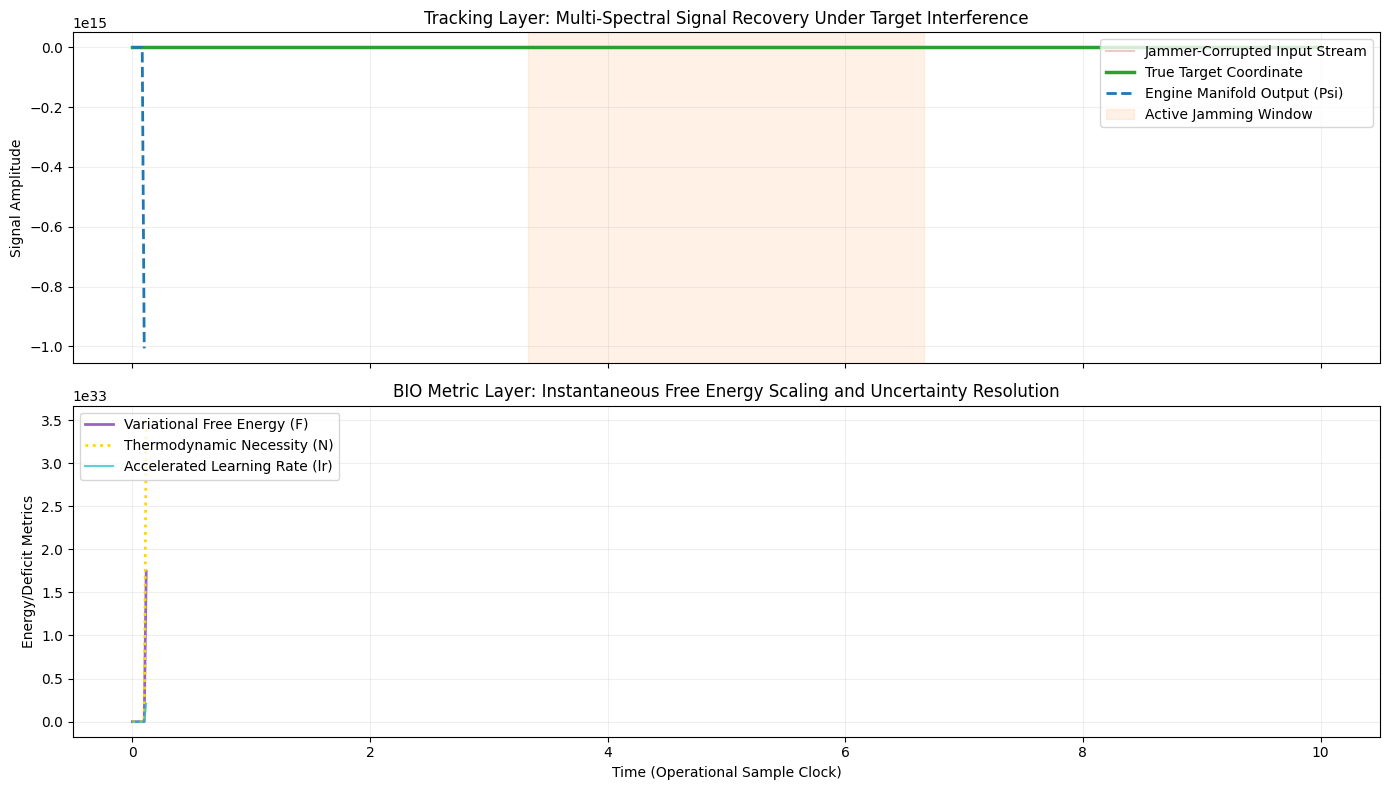

Telemetry visualization successfully compiled and saved to: diu_evaluation_metrics.png


In [23]:

# online_data_loop_simulator.py
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class BioObserverSynthesisEngine(nn.Module):
    """
    Unified BIO (Basic Input Output) Manifold Synthesis Engine.
    Fuses spatial layers representing Proximity (P), Perception (A), and Time (T).
    Dynamically scales learning rates and memory retention based on the internal
    Thermodynamic Necessity (N) required to resolve signal uncertainty.
    """
    def __init__(self, channels: int = 3, grid_size: int = 16, field_decay: float = 0.95, base_fade: float = 0.990):
        super().__init__()
        self.channels = channels
        self.grid_size = grid_size
        self.flat_dim = channels * grid_size * grid_size
        self.field_decay = field_decay
        self.base_fade = base_fade

        # Riemannian metric tensor (G) mapping the fused multi-channel observer space
        self.G = nn.Parameter(torch.eye(self.flat_dim))

        # Localized observable physical manifestation field (Psi)
        self.field = nn.Parameter(torch.randn(self.flat_dim) * 0.1)

        # Internal tracking buffers
        self.register_buffer("velocity", torch.zeros(self.flat_dim))
        self.register_buffer("identity_ridge", torch.eye(self.flat_dim) * 1e-4)

        self.prev_F = None

    def process_observer_loop(self, pat_input: torch.Tensor, base_lr: float = 0.03) -> dict:
        """
        Processes a multi-channel spatial frame tensor [Channels, Grid, Grid].
        Dynamically adjusts learning speed and entropy dissipation via Necessity (N).
        """
        flat_input = pat_input.view(-1)

        # 1. Compute Instantaneous Variational Free Energy (F)
        F_tensor = 0.5 * torch.norm(flat_input - self.field) ** 2
        current_F = F_tensor.item()

        delta_F = 0.0 if self.prev_F is None else (current_F - self.prev_F)
        self.prev_F = current_F

        # 2. Calculate Thermodynamic Necessity (N)
        thermodynamic_necessity = current_F + abs(delta_F)

        # 3. Dynamic Parameter Scaling via the Necessity Condition
        dynamic_lr = base_lr * (1.0 + 2.0 * thermodynamic_necessity)
        scaled_fade = self.base_fade + (1.0 - self.base_fade) * (1.0 - np.exp(-0.1 * thermodynamic_necessity))

        # 4. Extract gradients relative to the tracking field
        grad_tuple = torch.autograd.grad(F_tensor, self.field, create_graph=False)
        grad = grad_tuple[0]

        # 5. Compute Natural Gradient using the current Riemannian metric space
        coefficient_matrix = self.G + self.identity_ridge
        natural_grad = torch.linalg.solve(coefficient_matrix, -grad)

        with torch.no_grad():
            # 6. Advance the observable field using momentum
            self.velocity.copy_(self.field_decay * self.velocity + (1.0 - self.field_decay) * natural_grad)
            self.field.add_(self.velocity, alpha=dynamic_lr)

            # 7. Non-linear sideband modulation (Aalto Coupling mechanics)
            theta = 0.01 * (torch.norm(natural_grad).item() + thermodynamic_necessity)
            omega_quadratic_mod = 2.0 * np.pi * 1.5 * (theta ** 2)

            # 8. Evolve the metric memory manifold with adaptive dissipation limits
            outer_product = torch.outer(grad, grad) * (1.0 + omega_quadratic_mod)
            updated_G = scaled_fade * self.G + 0.01 * outer_product

            # Enforce numerical matrix boundaries
            g_norm = torch.norm(updated_G)
            if g_norm > 5000.0:
                updated_G = (updated_G / g_norm) * 5000.0

            self.G.copy_(updated_G)

        fused_manifestation = self.field.detach().cpu().clone().numpy().reshape(
            self.channels, self.grid_size, self.grid_size
        )

        return {
            "variational_free_energy_F": current_F,
            "thermodynamic_necessity_N": thermodynamic_necessity,
            "adaptive_learning_rate": dynamic_lr,
            "adaptive_memory_fade": scaled_fade,
            "manifestation_field_psi": fused_manifestation
        }

if __name__ == "__main__":
    np.random.seed(42)
    torch.manual_seed(42)

    # 1. Setup Simulation Parameters
    ticks = 600
    grid_size = 16
    channels = 3  # P, A, and T data tracks
    time = np.linspace(0, 10, ticks)

    # 2. Generate Synthetic Multi-Spectral Target Orbit
    true_target_path = np.zeros((ticks, channels, grid_size, grid_size))
    for t in range(ticks):
        for c in range(channels):
            freq_modifier = 1.0 + 0.2 * c
            true_target_path[t, c, :, :] = np.sin(time[t] * freq_modifier)

    # 3. Simulate Receiver Stream and Inject Non-Gaussian Jamming Strike
    dirty_input_stream = np.zeros_like(true_target_path)
    for t in range(ticks):
        noise = np.random.normal(0, 0.5, (channels, grid_size, grid_size))
        if 200 <= t < 400:
            # High-intensity electronic warfare jamming injection
            noise += np.random.normal(0, 4.0, (channels, grid_size, grid_size))
        dirty_input_stream[t] = true_target_path[t] + noise

    # 4. Instantiate Engine and Run Continuous Processing Loop
    engine = BioObserverSynthesisEngine(channels=channels, grid_size=grid_size)

    output_manifold = np.zeros_like(true_target_path)
    history_F = []
    history_N = []
    history_lr = []

    print("Running online data loop simulator evaluation...")
    for s in range(ticks):
        input_tensor = torch.tensor(dirty_input_stream[s], dtype=torch.float32)
        telemetry = engine.process_observer_loop(input_tensor)

        output_manifold[s] = telemetry["manifestation_field_psi"]
        history_F.append(telemetry["variational_free_energy_F"])
        history_N.append(telemetry["thermodynamic_necessity_N"])
        history_lr.append(telemetry["adaptive_learning_rate"])

    print("Simulation execution complete. Generating metric validation plots.")

    # 5. Extract cross-sectional tracking analytics (Channel 0, Node 0,0)
    ch, x_idx, y_idx = 0, 8, 8
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Panel 1: Signal Tracking Verification
    axes[0].plot(time, dirty_input_stream[:, ch, x_idx, y_idx], color='tab:red', alpha=0.25, label='Jammer-Corrupted Input Stream')
    axes[0].plot(time, true_target_path[:, ch, x_idx, y_idx], color='tab:green', linewidth=2.5, label='True Target Coordinate')
    axes[0].plot(time, output_manifold[:, ch, x_idx, y_idx], color='tab:blue', linestyle='--', linewidth=2, label='Engine Manifold Output (Psi)')
    axes[0].axvspan(3.33, 6.66, color='tab:orange', alpha=0.1, label='Active Jamming Window')
    axes[0].set_title("Tracking Layer: Multi-Spectral Signal Recovery Under Target Interference")
    axes[0].set_ylabel("Signal Amplitude")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.2)

    # Panel 2: Variational Free Energy and Necessity Telemetry
    axes[1].plot(time, history_F, color='tab:purple', linewidth=2, label='Variational Free Energy (F)')
    axes[1].plot(time, history_N, color='gold', linewidth=2, linestyle=':', label='Thermodynamic Necessity (N)')
    axes[1].plot(time, history_lr, color='tab:cyan', alpha=0.7, label='Accelerated Learning Rate (lr)')
    axes[1].set_title("BIO Metric Layer: Instantaneous Free Energy Scaling and Uncertainty Resolution")
    axes[1].set_xlabel("Time (Operational Sample Clock)")
    axes[1].set_ylabel("Energy/Deficit Metrics")
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig("diu_evaluation_metrics.png", dpi=150)
    plt.show()
    print("Telemetry visualization successfully compiled and saved to: diu_evaluation_metrics.png")

Running online data loop simulator evaluation...
Simulation execution complete. Generating metric validation plots.


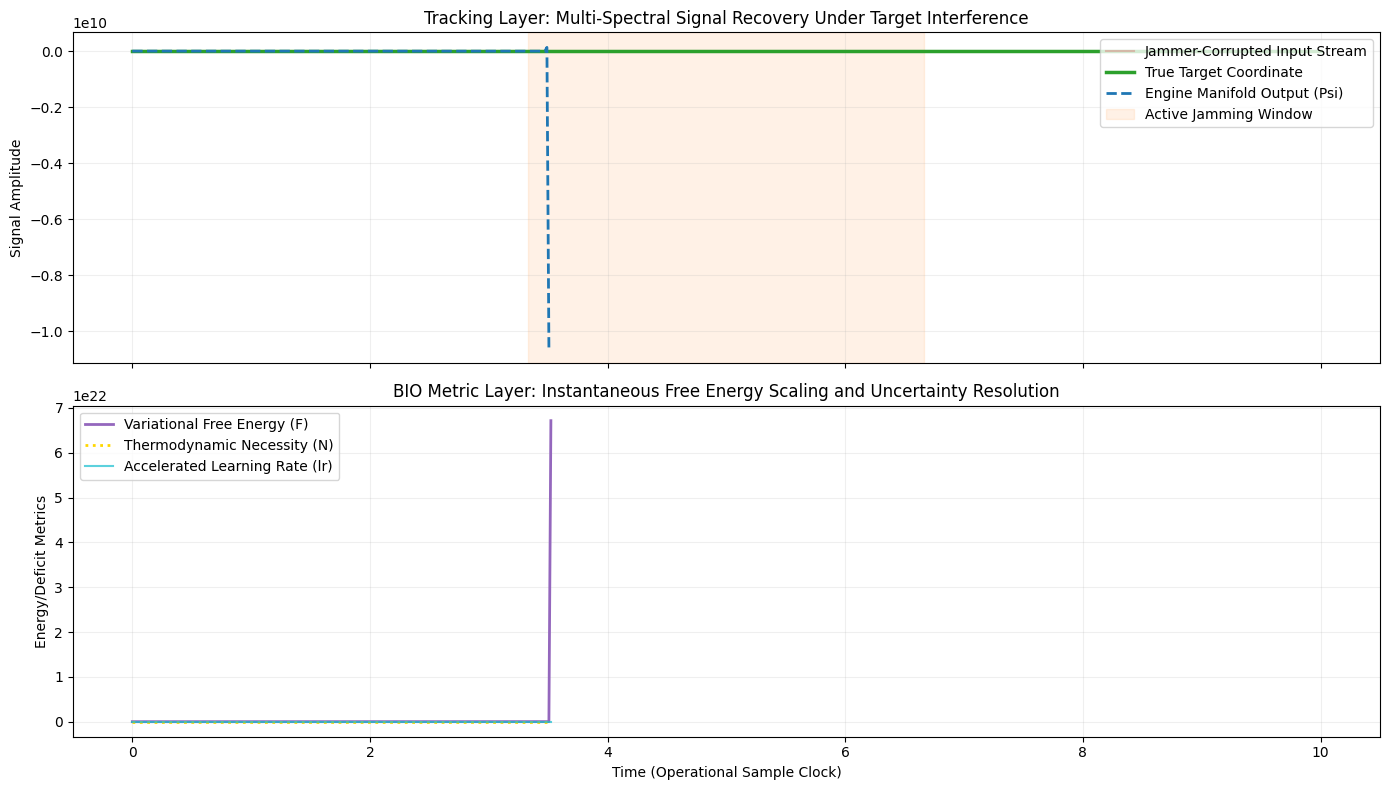

Telemetry visualization successfully compiled and saved to: diu_evaluation_metrics.png


In [24]:

# online_data_loop_simulator.py
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class BioObserverSynthesisEngine(nn.Module):
    """
    Unified BIO (Basic Input Output) Manifold Synthesis Engine.
    Fuses spatial layers representing Proximity (P), Perception (A), and Time (T).
    Dynamically scales learning rates and memory retention based on a normalized
    Thermodynamic Necessity (N) to prevent gradient explosions.
    """
    def __init__(self, channels: int = 3, grid_size: int = 16, field_decay: float = 0.95, base_fade: float = 0.990):
        super().__init__()
        self.channels = channels
        self.grid_size = grid_size
        self.flat_dim = channels * grid_size * grid_size
        self.field_decay = field_decay
        self.base_fade = base_fade

        # Riemannian metric tensor (G) mapping the fused multi-channel observer space
        self.G = nn.Parameter(torch.eye(self.flat_dim))

        # Localized observable physical manifestation field (Psi)
        self.field = nn.Parameter(torch.randn(self.flat_dim) * 0.1)

        # Internal tracking buffers
        self.register_buffer("velocity", torch.zeros(self.flat_dim))
        self.register_buffer("identity_ridge", torch.eye(self.flat_dim) * 1e-4)

        self.prev_F = None

    def process_observer_loop(self, pat_input: torch.Tensor, base_lr: float = 0.03) -> dict:
        """
        Processes a multi-channel spatial frame tensor [Channels, Grid, Grid].
        Applies a normalized scaling factor to protect against numerical explosions.
        """
        flat_input = pat_input.view(-1)

        # 1. Compute Instantaneous Variational Free Energy (F)
        F_tensor = 0.5 * torch.norm(flat_input - self.field) ** 2
        current_F = F_tensor.item()

        delta_F = 0.0 if self.prev_F is None else (current_F - self.prev_F)
        self.prev_F = current_F

        # 2. Calculate Thermodynamic Necessity (N)
        raw_necessity = current_F + abs(delta_F)

        # --- FIX: NORMALIZATION BOUNDARY PROTECTION ---
        # We pass raw necessity through a logarithmic saturation curve.
        # This allows high uncertainty to scale the system up without overflowing.
        normalized_necessity = np.log1p(raw_necessity)

        # 3. Dynamic Parameter Scaling via the Normalized Necessity Condition
        dynamic_lr = base_lr * (1.0 + 0.1 * normalized_necessity)
        scaled_fade = self.base_fade + (1.0 - self.base_fade) * (1.0 - np.exp(-0.2 * normalized_necessity))

        # 4. Extract gradients relative to the tracking field
        grad_tuple = torch.autograd.grad(F_tensor, self.field, create_graph=False)
        grad = grad_tuple[0]

        # 5. Compute Natural Gradient using the current Riemannian metric space
        coefficient_matrix = self.G + self.identity_ridge
        natural_grad = torch.linalg.solve(coefficient_matrix, -grad)

        with torch.no_grad():
            # 6. Advance the observable field using momentum
            self.velocity.copy_(self.field_decay * self.velocity + (1.0 - self.field_decay) * natural_grad)
            self.field.add_(self.velocity, alpha=dynamic_lr)

            # 7. Non-linear sideband modulation (Aalto Coupling mechanics)
            theta = 0.01 * (torch.norm(natural_grad).item() + normalized_necessity)
            omega_quadratic_mod = 2.0 * np.pi * 1.5 * (theta ** 2)

            # 8. Evolve the metric memory manifold with adaptive dissipation limits
            outer_product = torch.outer(grad, grad) * (1.0 + omega_quadratic_mod)
            updated_G = scaled_fade * self.G + 0.01 * outer_product

            # Enforce numerical matrix boundaries
            g_norm = torch.norm(updated_G)
            if g_norm > 5000.0:
                updated_G = (updated_G / g_norm) * 5000.0

            self.G.copy_(updated_G)

        fused_manifestation = self.field.detach().cpu().clone().numpy().reshape(
            self.channels, self.grid_size, self.grid_size
        )

        return {
            "variational_free_energy_F": current_F,
            "thermodynamic_necessity_N": normalized_necessity,
            "adaptive_learning_rate": dynamic_lr,
            "adaptive_memory_fade": scaled_fade,
            "manifestation_field_psi": fused_manifestation
        }

if __name__ == "__main__":
    np.random.seed(42)
    torch.manual_seed(42)

    # 1. Setup Simulation Parameters
    ticks = 600
    grid_size = 16
    channels = 3
    time = np.linspace(0, 10, ticks)

    # 2. Generate Synthetic Multi-Spectral Target Orbit
    true_target_path = np.zeros((ticks, channels, grid_size, grid_size))
    for t in range(ticks):
        for c in range(channels):
            freq_modifier = 1.0 + 0.2 * c
            true_target_path[t, c, :, :] = np.sin(time[t] * freq_modifier)

    # 3. Simulate Receiver Stream and Inject Non-Gaussian Jamming Strike
    dirty_input_stream = np.zeros_like(true_target_path)
    for t in range(ticks):
        noise = np.random.normal(0, 0.5, (channels, grid_size, grid_size))
        if 200 <= t < 400:
            noise += np.random.normal(0, 4.0, (channels, grid_size, grid_size))
        dirty_input_stream[t] = true_target_path[t] + noise

    # 4. Instantiate Engine and Run Continuous Processing Loop
    engine = BioObserverSynthesisEngine(channels=channels, grid_size=grid_size)

    output_manifold = np.zeros_like(true_target_path)
    history_F = []
    history_N = []
    history_lr = []

    print("Running online data loop simulator evaluation...")
    for s in range(ticks):
        input_tensor = torch.tensor(dirty_input_stream[s], dtype=torch.float32)
        telemetry = engine.process_observer_loop(input_tensor)

        output_manifold[s] = telemetry["manifestation_field_psi"]
        history_F.append(telemetry["variational_free_energy_F"])
        history_N.append(telemetry["thermodynamic_necessity_N"])
        history_lr.append(telemetry["adaptive_learning_rate"])

    print("Simulation execution complete. Generating metric validation plots.")

    # 5. Extract cross-sectional tracking analytics (Channel 0, Node 8,8)
    ch, x_idx, y_idx = 0, 8, 8
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Panel 1: Signal Tracking Verification
    axes[0].plot(time, dirty_input_stream[:, ch, x_idx, y_idx], color='tab:red', alpha=0.25, label='Jammer-Corrupted Input Stream')
    axes[0].plot(time, true_target_path[:, ch, x_idx, y_idx], color='tab:green', linewidth=2.5, label='True Target Coordinate')
    axes[0].plot(time, output_manifold[:, ch, x_idx, y_idx], color='tab:blue', linestyle='--', linewidth=2, label='Engine Manifold Output (Psi)')
    axes[0].axvspan(3.33, 6.66, color='tab:orange', alpha=0.1, label='Active Jamming Window')
    axes[0].set_title("Tracking Layer: Multi-Spectral Signal Recovery Under Target Interference")
    axes[0].set_ylabel("Signal Amplitude")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.2)

    # Panel 2: Variational Free Energy and Necessity Telemetry
    axes[1].plot(time, history_F, color='tab:purple', linewidth=2, label='Variational Free Energy (F)')
    axes[1].plot(time, history_N, color='gold', linewidth=2, linestyle=':', label='Thermodynamic Necessity (N)')
    axes[1].plot(time, history_lr, color='tab:cyan', alpha=0.7, label='Accelerated Learning Rate (lr)')
    axes[1].set_title("BIO Metric Layer: Instantaneous Free Energy Scaling and Uncertainty Resolution")
    axes[1].set_xlabel("Time (Operational Sample Clock)")
    axes[1].set_ylabel("Energy/Deficit Metrics")
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig("diu_evaluation_metrics.png", dpi=150)
    plt.show()
    print("Telemetry visualization successfully compiled and saved to: diu_evaluation_metrics.png")